In [1]:
from pathlib import Path

import pandas as pd

path_data = Path.cwd().parent / "data"

df_fred_statement_dates = pd.read_csv(
    path_data / "df_fred_statement_dates.csv",
    parse_dates=["date"],
)

period_sentiment_scores = pd.read_csv(
    path_data / "period_sentiment_scores.csv",
    parse_dates=["start_date", "end_date"],
)

period_sentiment_scores_fixed = pd.read_csv(
    path_data / "period_sentiment_scores_fixed.csv",
    parse_dates=["start_date", "end_date"],
)

df_fred_statement_dates.tail()

,date,lower_value,upper_value,upper_rate_change
91,2026-03-18,3.50,3.75,0.00
92,2026-04-29,3.50,3.75,0.00
93,2026-06-17,3.50,3.75,0.00
94,2026-07-29,3.50,3.75,0.00
95,2026-09-16,3.75,4.00,0.25


Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\upper_rate_change_by_fomc_period.png


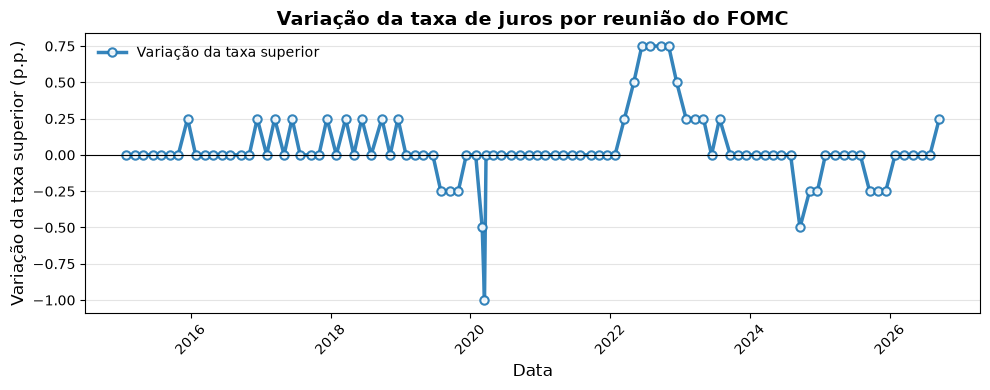

In [18]:
import matplotlib.pyplot as plt

rate_evolution = df_fred_statement_dates.sort_values("date").copy()
rate_evolution["date"] = pd.to_datetime(rate_evolution["date"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    rate_evolution["date"],
    rate_evolution["upper_rate_change"],
    marker="o",
    markerfacecolor="white",
    markeredgewidth=1.5,
    linewidth=2.5,
    color="tab:blue",
    alpha=0.9,
    label="Variação da taxa superior",
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Data", fontsize=12)
ax.set_ylabel("Variação da taxa superior (p.p.)", fontsize=12)
ax.set_title(
    "Variação da taxa de juros por reunião do FOMC",
    fontsize=14,
    fontweight="bold",
)
ax.grid(True, axis="y", color="#D9D9D9", alpha=0.7)
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left", fontsize=10, frameon=False)

plt.tight_layout()
output_path = path_data.parent / "TCC_latex" / "figuras" / "upper_rate_change_by_fomc_period.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Figure saved to {output_path}")
plt.show()


In [3]:
period_sentiment_scores.head()

,start_date,end_date,node_count,relationship_count,number_of_leiden_communities,largest_leiden_community_size,leiden_equal_weight_sentiment,leiden_betweenness_weighted_sentiment,leiden_degree_weighted_sentiment,leiden_pagerank_weighted_sentiment,simple_mean_sentiment,betweenness_weighted_sentiment,degree_weighted_sentiment,pagerank_weighted_sentiment,similarity_cutoff
0,2015-01-28,2015-03-18,66,2516,5,23,-0.293497,-0.320300,-0.347945,-0.342457,-0.295455,-0.331247,-0.412501,-0.377661,0.71
1,2015-03-18,2015-04-29,114,6712,5,32,-0.269858,-0.267289,-0.289873,-0.287589,-0.271930,-0.308037,-0.325871,-0.311888,0.72
2,2015-04-29,2015-06-17,73,2236,5,27,-0.226465,-0.095612,-0.217507,-0.218550,-0.267123,-0.306474,-0.308506,-0.299071,0.73
3,2015-06-17,2015-07-29,106,5072,6,25,-0.260305,-0.278081,-0.287762,-0.287993,-0.297170,-0.291188,-0.401612,-0.366963,0.74
4,2015-07-29,2015-09-17,48,1556,5,12,-0.212381,-0.333108,-0.270463,-0.241466,-0.270833,-0.303870,-0.355758,-0.325187,0.72


In [4]:
period_sentiment_scores_fixed.head()

,start_date,end_date,node_count,relationship_count,number_of_leiden_communities,largest_leiden_community_size,leiden_equal_weight_sentiment,leiden_betweenness_weighted_sentiment,leiden_degree_weighted_sentiment,leiden_pagerank_weighted_sentiment,simple_mean_sentiment,betweenness_weighted_sentiment,degree_weighted_sentiment,pagerank_weighted_sentiment,similarity_cutoff
0,2015-01-28,2015-03-18,63,1976,5,23,-0.327014,-0.613690,-0.393442,-0.386918,-0.309524,-0.556655,-0.439581,-0.401183,0.72
1,2015-03-18,2015-04-29,114,6712,5,32,-0.269858,-0.267289,-0.289873,-0.287589,-0.271930,-0.308037,-0.325871,-0.311888,0.72
2,2015-04-29,2015-06-17,73,2792,4,23,-0.254220,-0.155078,-0.293298,-0.272651,-0.267123,-0.105348,-0.285179,-0.279008,0.72
3,2015-06-17,2015-07-29,106,6920,4,46,-0.257949,-0.265675,-0.276352,-0.275937,-0.297170,-0.320242,-0.373133,-0.349567,0.72
4,2015-07-29,2015-09-17,48,1556,5,12,-0.212381,-0.333108,-0.270463,-0.241466,-0.270833,-0.303870,-0.355758,-0.325187,0.72


In [2]:
sentiment_columns = [
    "betweenness_weighted_sentiment",
    "degree_weighted_sentiment",
    "pagerank_weighted_sentiment",
    "leiden_equal_weight_sentiment",
    "leiden_betweenness_weighted_sentiment",
    "leiden_degree_weighted_sentiment",
    "leiden_pagerank_weighted_sentiment",
    "simple_mean_sentiment",
]

sentiment_labels = {
    "betweenness_weighted_sentiment": "Betweenness",
    "degree_weighted_sentiment": "Grau",
    "pagerank_weighted_sentiment": "PageRank",
    "leiden_equal_weight_sentiment": "Comunidades Leiden",
    "leiden_betweenness_weighted_sentiment": "Leiden + Betweenness",
    "leiden_degree_weighted_sentiment": "Leiden + Grau",
    "leiden_pagerank_weighted_sentiment": "Leiden + PageRank",
    "simple_mean_sentiment": "Média simples",
}


def calculate_rate_correlations(sentiment_scores):
    correlation_data = sentiment_scores.copy()
    correlation_data["end_date"] = pd.to_datetime(correlation_data["end_date"])
    correlation_data = correlation_data.merge(
        df_fred_statement_dates[["date", "upper_rate_change"]],
        left_on="end_date",
        right_on="date",
        how="inner",
    )

    correlation_values = correlation_data[sentiment_columns + ["upper_rate_change"]]
    correlations = correlation_values.corr(method="pearson")["upper_rate_change"].drop(
        "upper_rate_change"
    )
    correlations_spearman = correlation_values.corr(method="spearman")[
        "upper_rate_change"
    ].drop("upper_rate_change")

    correlations = correlations.rename(index=sentiment_labels)
    correlations_spearman = correlations_spearman.rename(index=sentiment_labels)
    correlations = pd.DataFrame(
        {
            "correlacao_pearson": correlations,
            "correlacao_spearman": correlations_spearman,
        }
    )
    correlations = correlations.round(3)
    correlations["correlacao_abs"] = correlations["correlacao_pearson"].abs()
    return correlations.sort_values("correlacao_abs", ascending=False).drop(
        columns="correlacao_abs"
    )


correlacoes_limiar_variavel = calculate_rate_correlations(period_sentiment_scores)
correlacoes_limiar_fixo = calculate_rate_correlations(period_sentiment_scores_fixed)

print("Correlação com upper_rate_change - limiar variável")
display(correlacoes_limiar_variavel)

print("Correlação com upper_rate_change - limiar fixo")
display(correlacoes_limiar_fixo)


Correlação com upper_rate_change - limiar variável


,correlacao_pearson,correlacao_spearman
Comunidades Leiden,0.495,0.468
Leiden + Grau,0.486,0.477
Leiden + PageRank,0.486,0.473
Média simples,0.485,0.497
PageRank,0.477,0.495
Grau,0.475,0.495
Betweenness,0.460,0.460
Leiden + Betweenness,0.458,0.438


Correlação com upper_rate_change - limiar fixo


,correlacao_pearson,correlacao_spearman
Betweenness,0.503,0.483
Média simples,0.485,0.497
PageRank,0.480,0.497
Grau,0.477,0.501
Leiden + Betweenness,0.476,0.460
Comunidades Leiden,0.451,0.436
Leiden + PageRank,0.449,0.440
Leiden + Grau,0.448,0.451


In [3]:
import statsmodels.api as sm


def estimate_anticipation_regressions(sentiment_scores, dataset_name, maxlags=1):
    """Compare each period indicator with the next and preceding FOMC decisions."""
    decision_rates = (
        df_fred_statement_dates[["date", "upper_rate_change"]]
        .assign(date=lambda frame: pd.to_datetime(frame["date"]))
        .sort_values("date")
    )
    sample = sentiment_scores.copy()
    sample["start_date"] = pd.to_datetime(sample["start_date"])
    sample["end_date"] = pd.to_datetime(sample["end_date"])
    sample = (
        sample.merge(
            decision_rates.rename(
                columns={"date": "end_date", "upper_rate_change": "rate_change_next"}
            ),
            on="end_date",
            how="inner",
        )
        .merge(
            decision_rates.rename(
                columns={"date": "start_date", "upper_rate_change": "rate_change_previous"}
            ),
            on="start_date",
            how="inner",
        )
        .sort_values("end_date")
    )

    regression_results = []
    for indicator in sentiment_columns:
        model_data = sample[[indicator, "rate_change_next", "rate_change_previous"]].dropna()
        design_matrix = sm.add_constant(model_data[[indicator]], has_constant="add")
        hac_lags = min(maxlags, len(model_data) - 1)
        next_decision_model = sm.OLS(model_data["rate_change_next"], design_matrix).fit(
            cov_type="HAC", cov_kwds={"maxlags": hac_lags}
        )
        previous_decision_model = sm.OLS(
            model_data["rate_change_previous"], design_matrix
        ).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

        beta_next = next_decision_model.params[indicator]
        p_value_next = next_decision_model.pvalues[indicator]
        beta_previous = previous_decision_model.params[indicator]
        regression_results.append(
            {
                "amostra": dataset_name,
                "indicador": sentiment_labels[indicator],
                "n_observacoes": len(model_data),
                "beta_decisao_seguinte": beta_next,
                "p_valor_hac_decisao_seguinte": p_value_next,
                "r2_decisao_seguinte": next_decision_model.rsquared,
                "beta_decisao_anterior": beta_previous,
                "p_valor_hac_decisao_anterior": previous_decision_model.pvalues[indicator],
                "r2_decisao_anterior": previous_decision_model.rsquared,
                "beta_positivo_significativo": beta_next > 0 and p_value_next < 0.05,
                "associacao_maior_com_decisao_seguinte": abs(beta_next) > abs(beta_previous),
            }
        )

    return pd.DataFrame(regression_results).sort_values(
        ["beta_positivo_significativo", "p_valor_hac_decisao_seguinte"],
        ascending=[False, True],
    )


antecipacao_limiar_variavel = estimate_anticipation_regressions(
    period_sentiment_scores, "Limiar variavel"
)
antecipacao_limiar_fixo = estimate_anticipation_regressions(
    period_sentiment_scores_fixed, "Limiar fixo"
)

antecipacao_resultados = pd.concat(
    [antecipacao_limiar_variavel, antecipacao_limiar_fixo], ignore_index=True
).round(4)

print("Regressoes HAC/Newey-West: indicador do periodo e decisao na reuniao seguinte")
display(antecipacao_resultados)

print("Indicadores com beta positivo e estatisticamente diferente de zero (5%):")
display(
    antecipacao_resultados.loc[
        antecipacao_resultados["beta_positivo_significativo"],
        [
            "amostra",
            "indicador",
            "beta_decisao_seguinte",
            "p_valor_hac_decisao_seguinte",
            "r2_decisao_seguinte",
        ],
    ]
)

Regressoes HAC/Newey-West: indicador do periodo e decisao na reuniao seguinte


,amostra,indicador,n_observacoes,beta_decisao_seguinte,p_valor_hac_decisao_seguinte,r2_decisao_seguinte,beta_decisao_anterior,p_valor_hac_decisao_anterior,r2_decisao_anterior,beta_positivo_significativo,associacao_maior_com_decisao_seguinte
0,Limiar variavel,Grau,95,0.3000,0.0005,0.2253,0.3199,0.0004,0.2582,True,False
1,Limiar variavel,PageRank,95,0.3134,0.0005,0.2275,0.3346,0.0003,0.2614,True,False
2,Limiar variavel,Média simples,95,0.3555,0.0005,0.2357,0.3838,0.0003,0.2769,True,False
3,Limiar variavel,Leiden + Grau,95,0.3392,0.0006,0.2358,0.3696,0.0003,0.2821,True,False
4,Limiar variavel,Leiden + PageRank,95,0.3482,0.0006,0.2362,0.3773,0.0003,0.2795,True,False
5,Limiar variavel,Betweenness,95,0.3126,0.0006,0.2112,0.3316,0.0006,0.2394,True,False
6,Limiar variavel,Comunidades Leiden,95,0.3845,0.0007,0.2446,0.4150,0.0003,0.2873,True,False
7,Limiar variavel,Leiden + Betweenness,95,0.3253,0.0010,0.2100,0.3549,0.0005,0.2518,True,False
8,Limiar fixo,Grau,95,0.2986,0.0004,0.2275,0.3178,0.0003,0.2598,True,False
9,Limiar fixo,Betweenness,95,0.3365,0.0005,0.2529,0.3582,0.0002,0.2889,True,False


Indicadores com beta positivo e estatisticamente diferente de zero (5%):


,amostra,indicador,beta_decisao_seguinte,p_valor_hac_decisao_seguinte,r2_decisao_seguinte
0,Limiar variavel,Grau,0.3000,0.0005,0.2253
1,Limiar variavel,PageRank,0.3134,0.0005,0.2275
2,Limiar variavel,Média simples,0.3555,0.0005,0.2357
3,Limiar variavel,Leiden + Grau,0.3392,0.0006,0.2358
4,Limiar variavel,Leiden + PageRank,0.3482,0.0006,0.2362
5,Limiar variavel,Betweenness,0.3126,0.0006,0.2112
6,Limiar variavel,Comunidades Leiden,0.3845,0.0007,0.2446
7,Limiar variavel,Leiden + Betweenness,0.3253,0.0010,0.2100
8,Limiar fixo,Grau,0.2986,0.0004,0.2275
9,Limiar fixo,Betweenness,0.3365,0.0005,0.2529


In [5]:
import numpy as np


def build_prediction_sample(sentiment_scores):
    decision_rates = (
        df_fred_statement_dates[["date", "upper_rate_change"]]
        .assign(date=lambda frame: pd.to_datetime(frame["date"]))
        .sort_values("date")
    )
    sample = sentiment_scores.copy()
    sample["end_date"] = pd.to_datetime(sample["end_date"])
    return (
        sample.merge(
            decision_rates.rename(
                columns={"date": "end_date", "upper_rate_change": "rate_change_next"}
            ),
            on="end_date",
            how="inner",
        )
        .sort_values("end_date")
        .reset_index(drop=True)
    )


def expanding_window_predictions(model_data, predictors, min_train_size=30):
    predictions = []
    for test_index in range(min_train_size, len(model_data)):
        train_data = model_data.iloc[:test_index]
        test_data = model_data.iloc[[test_index]]
        model = sm.OLS(
            train_data["rate_change_next"],
            sm.add_constant(train_data[predictors], has_constant="add"),
        ).fit()
        prediction = model.predict(
            sm.add_constant(test_data[predictors], has_constant="add")
        ).iloc[0]
        predictions.append(
            {
                "observed": test_data["rate_change_next"].iloc[0],
                "predicted": prediction,
            }
        )
    return pd.DataFrame(predictions)


def compare_graph_incremental_value(sentiment_scores, dataset_name, maxlags=1):
    sample = build_prediction_sample(sentiment_scores)
    graph_indicators = [
        indicator for indicator in sentiment_columns if indicator != "simple_mean_sentiment"
    ]
    comparison_results = []

    for graph_indicator in graph_indicators:
        model_data = sample[
            ["simple_mean_sentiment", graph_indicator, "rate_change_next"]
        ].dropna()
        base_predictors = ["simple_mean_sentiment"]
        graph_predictors = ["simple_mean_sentiment", graph_indicator]
        hac_lags = min(maxlags, len(model_data) - 1)

        model_base = sm.OLS(
            model_data["rate_change_next"],
            sm.add_constant(model_data[base_predictors], has_constant="add"),
        ).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
        model_graph = sm.OLS(
            model_data["rate_change_next"],
            sm.add_constant(model_data[graph_predictors], has_constant="add"),
        ).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

        base_predictions = expanding_window_predictions(model_data, base_predictors)
        graph_predictions = expanding_window_predictions(model_data, graph_predictors)
        observed = base_predictions["observed"]
        base_errors = observed - base_predictions["predicted"]
        graph_errors = observed - graph_predictions["predicted"]

        comparison_results.append(
            {
                "amostra": dataset_name,
                "indicador_grafo": sentiment_labels[graph_indicator],
                "n_observacoes": len(model_data),
                "r2_m0_media_simples": model_base.rsquared,
                "r2_ajustado_m0": model_base.rsquared_adj,
                "r2_m1_com_grafo": model_graph.rsquared,
                "r2_ajustado_m1": model_graph.rsquared_adj,
                "ganho_r2_ajustado": model_graph.rsquared_adj - model_base.rsquared_adj,
                "beta_indicador_grafo": model_graph.params[graph_indicator],
                "p_valor_hac_indicador_grafo": model_graph.pvalues[graph_indicator],
                "rmse_oos_m0": np.sqrt(np.mean(base_errors**2)),
                "rmse_oos_m1": np.sqrt(np.mean(graph_errors**2)),
                "ganho_rmse_oos": np.sqrt(np.mean(base_errors**2)) - np.sqrt(np.mean(graph_errors**2)),
                "mae_oos_m0": np.mean(np.abs(base_errors)),
                "mae_oos_m1": np.mean(np.abs(graph_errors)),
                "acuracia_direcao_oos_m0": np.mean(
                    np.sign(base_predictions["predicted"]) == np.sign(observed)
                ),
                "acuracia_direcao_oos_m1": np.mean(
                    np.sign(graph_predictions["predicted"]) == np.sign(observed)
                ),
            }
        )

    results = pd.DataFrame(comparison_results)
    results["ganho_acuracia_direcao_oos"] = (
        results["acuracia_direcao_oos_m1"] - results["acuracia_direcao_oos_m0"]
    )
    results["valor_incremental"] = (
        (results["p_valor_hac_indicador_grafo"] < 0.05)
        & (results["ganho_r2_ajustado"] > 0)
        & (results["ganho_rmse_oos"] > 0)
    )
    return results.sort_values(
        ["valor_incremental", "ganho_rmse_oos"], ascending=[False, False]
    )


valor_incremental_limiar_variavel = compare_graph_incremental_value(
    period_sentiment_scores, "Limiar variavel"
)
valor_incremental_limiar_fixo = compare_graph_incremental_value(
    period_sentiment_scores_fixed, "Limiar fixo"
)
valor_incremental_resultados = pd.concat(
    [valor_incremental_limiar_variavel, valor_incremental_limiar_fixo],
    ignore_index=True,
).round(4)

print("Valor incremental dos indicadores de grafo em relacao a media simples")
display(valor_incremental_resultados)

print("Modelos com ganho de R2 ajustado, RMSE fora da amostra e coeficiente HAC significativo:")
display(valor_incremental_resultados.loc[valor_incremental_resultados["valor_incremental"]])

Valor incremental dos indicadores de grafo em relacao a media simples


,amostra,indicador_grafo,n_observacoes,r2_m0_media_simples,r2_ajustado_m0,r2_m1_com_grafo,r2_ajustado_m1,ganho_r2_ajustado,beta_indicador_grafo,p_valor_hac_indicador_grafo,rmse_oos_m0,rmse_oos_m1,ganho_rmse_oos,mae_oos_m0,mae_oos_m1,acuracia_direcao_oos_m0,acuracia_direcao_oos_m1,ganho_acuracia_direcao_oos,valor_incremental
0,Limiar variavel,Leiden + Betweenness,95,0.2357,0.2275,0.2386,0.2220,-0.0055,-0.1580,0.4881,0.2522,0.2531,-0.0009,0.1898,0.1903,0.2462,0.2769,0.0308,False
1,Limiar variavel,Leiden + Grau,95,0.2357,0.2275,0.2372,0.2206,-0.0069,0.1745,0.5380,0.2522,0.2537,-0.0015,0.1898,0.1903,0.2462,0.2615,0.0154,False
2,Limiar variavel,Leiden + PageRank,95,0.2357,0.2275,0.2373,0.2207,-0.0068,0.1928,0.5635,0.2522,0.2542,-0.0020,0.1898,0.1903,0.2462,0.2615,0.0154,False
3,Limiar variavel,Grau,95,0.2357,0.2275,0.2414,0.2249,-0.0026,-0.4480,0.4027,0.2522,0.2551,-0.0029,0.1898,0.1911,0.2462,0.2615,0.0154,False
4,Limiar variavel,Betweenness,95,0.2357,0.2275,0.2406,0.2241,-0.0034,-0.2231,0.5326,0.2522,0.2553,-0.0031,0.1898,0.1948,0.2462,0.2615,0.0154,False
5,Limiar variavel,PageRank,95,0.2357,0.2275,0.2442,0.2278,0.0003,-0.7927,0.3644,0.2522,0.2560,-0.0038,0.1898,0.1908,0.2462,0.2615,0.0154,False
6,Limiar variavel,Comunidades Leiden,95,0.2357,0.2275,0.2451,0.2287,0.0012,0.4865,0.3942,0.2522,0.2589,-0.0067,0.1898,0.1904,0.2462,0.2615,0.0154,False
7,Limiar fixo,Betweenness,95,0.2357,0.2275,0.2541,0.2378,0.0104,0.4494,0.1034,0.2522,0.2501,0.0021,0.1898,0.1882,0.2462,0.2615,0.0154,False
8,Limiar fixo,Leiden + Betweenness,95,0.2357,0.2275,0.2371,0.2205,-0.0070,0.0942,0.7038,0.2522,0.2542,-0.0020,0.1898,0.1934,0.2462,0.2462,0.0000,False
9,Limiar fixo,PageRank,95,0.2357,0.2275,0.2379,0.2213,-0.0061,-0.3982,0.5859,0.2522,0.2548,-0.0026,0.1898,0.1906,0.2462,0.2615,0.0154,False


Modelos com ganho de R2 ajustado, RMSE fora da amostra e coeficiente HAC significativo:


,amostra,indicador_grafo,n_observacoes,r2_m0_media_simples,r2_ajustado_m0,r2_m1_com_grafo,r2_ajustado_m1,ganho_r2_ajustado,beta_indicador_grafo,p_valor_hac_indicador_grafo,rmse_oos_m0,rmse_oos_m1,ganho_rmse_oos,mae_oos_m0,mae_oos_m1,acuracia_direcao_oos_m0,acuracia_direcao_oos_m1,ganho_acuracia_direcao_oos,valor_incremental


In [7]:
def classify_rate_direction(values, threshold=0.125):
    values = np.asarray(values)
    return np.select(
        [values > threshold, values < -threshold],
        ["Alta", "Corte"],
        default="Manutencao",
    )


def temporal_out_of_sample_validation(
    sentiment_scores, dataset_name, min_train_size=30, direction_threshold=0.125
):
    sample = build_prediction_sample(sentiment_scores)
    model_specs = {"Media historica": []}
    model_specs.update(
        {sentiment_labels[indicator]: [indicator] for indicator in sentiment_columns}
    )
    all_predictions = []

    for model_name, predictors in model_specs.items():
        model_data = sample[["end_date", "rate_change_next", *predictors]].dropna()
        for test_index in range(min_train_size, len(model_data)):
            train_data = model_data.iloc[:test_index]
            test_data = model_data.iloc[[test_index]]
            if predictors:
                model = sm.OLS(
                    train_data["rate_change_next"],
                    sm.add_constant(train_data[predictors], has_constant="add"),
                ).fit()
                prediction = model.predict(
                    sm.add_constant(test_data[predictors], has_constant="add")
                ).iloc[0]
            else:
                prediction = train_data["rate_change_next"].mean()

            observed = test_data["rate_change_next"].iloc[0]
            all_predictions.append(
                {
                    "amostra": dataset_name,
                    "modelo": model_name,
                    "data_previsao": test_data["end_date"].iloc[0],
                    "n_treino": len(train_data),
                    "variacao_observada": observed,
                    "variacao_prevista": prediction,
                    "direcao_observada": classify_rate_direction(
                        [observed], direction_threshold
                    )[0],
                    "direcao_prevista": classify_rate_direction(
                        [prediction], direction_threshold
                    )[0],
                }
            )

    predictions = pd.DataFrame(all_predictions)
    metrics = (
        predictions.assign(
            erro=lambda frame: frame["variacao_observada"] - frame["variacao_prevista"],
            direcao_correta=lambda frame: (
                frame["direcao_observada"] == frame["direcao_prevista"]
            ),
        )
        .groupby(["amostra", "modelo"], as_index=False)
        .agg(
            n_previsoes=("erro", "size"),
            inicio_teste=("data_previsao", "min"),
            fim_teste=("data_previsao", "max"),
            mae_oos=("erro", lambda errors: np.mean(np.abs(errors))),
            rmse_oos=("erro", lambda errors: np.sqrt(np.mean(errors**2))),
            acuracia_direcao_oos=("direcao_correta", "mean"),
        )
        .sort_values(["amostra", "rmse_oos"])
        .reset_index(drop=True)
    )
    return metrics, predictions


validacao_temporal_limiar_variavel, previsoes_temporais_limiar_variavel = (
    temporal_out_of_sample_validation(period_sentiment_scores, "Limiar variavel")
)
validacao_temporal_limiar_fixo, previsoes_temporais_limiar_fixo = (
    temporal_out_of_sample_validation(period_sentiment_scores_fixed, "Limiar fixo")
)
validacao_temporal_resultados = pd.concat(
    [validacao_temporal_limiar_variavel, validacao_temporal_limiar_fixo],
    ignore_index=True,
)
metric_columns = ["mae_oos", "rmse_oos", "acuracia_direcao_oos"]
validacao_temporal_resultados[metric_columns] = validacao_temporal_resultados[
    metric_columns
].round(4)
previsoes_temporais = pd.concat(
    [previsoes_temporais_limiar_variavel, previsoes_temporais_limiar_fixo],
    ignore_index=True,
)

print("Validacao temporal fora da amostra com janela expansiva")
print("Treino inicial: 30 reunioes; classificacao: corte (< -0,125), manutencao e alta (> 0,125).")
display(validacao_temporal_resultados)

print("Primeiras previsoes fora da amostra:")
display(previsoes_temporais.head(10))

Validacao temporal fora da amostra com janela expansiva
Treino inicial: 30 reunioes; classificacao: corte (< -0,125), manutencao e alta (> 0,125).


,amostra,modelo,n_previsoes,inicio_teste,fim_teste,mae_oos,rmse_oos,acuracia_direcao_oos
0,Limiar variavel,Comunidades Leiden,65,2018-12-19,2026-09-16,0.1899,0.2520,0.5077
1,Limiar variavel,Média simples,65,2018-12-19,2026-09-16,0.1898,0.2522,0.4923
2,Limiar variavel,Leiden + Grau,65,2018-12-19,2026-09-16,0.1889,0.2526,0.4769
3,Limiar variavel,Leiden + PageRank,65,2018-12-19,2026-09-16,0.1889,0.2526,0.4923
4,Limiar variavel,PageRank,65,2018-12-19,2026-09-16,0.1900,0.2531,0.4769
5,Limiar variavel,Grau,65,2018-12-19,2026-09-16,0.1909,0.2534,0.4769
6,Limiar variavel,Betweenness,65,2018-12-19,2026-09-16,0.1827,0.2550,0.5077
7,Limiar variavel,Leiden + Betweenness,65,2018-12-19,2026-09-16,0.1857,0.2559,0.4923
8,Limiar variavel,Media historica,65,2018-12-19,2026-09-16,0.1721,0.2847,0.6308
9,Limiar fixo,Betweenness,65,2018-12-19,2026-09-16,0.1854,0.2490,0.5077


Primeiras previsoes fora da amostra:


,amostra,modelo,data_previsao,n_treino,variacao_observada,variacao_prevista,direcao_observada,direcao_prevista
0,Limiar variavel,Media historica,2018-12-19,30,0.25,0.066667,Alta,Manutencao
1,Limiar variavel,Media historica,2019-01-30,31,0.00,0.072581,Manutencao,Manutencao
2,Limiar variavel,Media historica,2019-03-20,32,0.00,0.070312,Manutencao,Manutencao
3,Limiar variavel,Media historica,2019-05-01,33,0.00,0.068182,Manutencao,Manutencao
4,Limiar variavel,Media historica,2019-06-19,34,0.00,0.066176,Manutencao,Manutencao
5,Limiar variavel,Media historica,2019-07-31,35,-0.25,0.064286,Corte,Manutencao
6,Limiar variavel,Media historica,2019-09-18,36,-0.25,0.055556,Corte,Manutencao
7,Limiar variavel,Media historica,2019-10-30,37,-0.25,0.047297,Corte,Manutencao
8,Limiar variavel,Media historica,2019-12-11,38,0.00,0.039474,Manutencao,Manutencao
9,Limiar variavel,Media historica,2020-01-29,39,0.00,0.038462,Manutencao,Manutencao
